In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard, ReduceLROnPlateau
from tensorflow import keras
from tensorflow.keras.layers import Dense, Input, BatchNormalization, Activation, Dropout
from tensorflow.keras.models import Sequential
from src.metrics import metrics
from src.load_data import get_dataset, prepare_df
from src.pipeline import get_preprocessor
from sklearn.model_selection import train_test_split
import tensorflow as tf
import os
seed = 42
tf.keras.utils.set_random_seed(seed)
tf.config.experimental.enable_op_determinism()
os.environ["PYTHONHASHSEED"] = str(seed)

In [2]:
df = get_dataset()

In [3]:
X_train_val, X_test, y_train_val, y_test = prepare_df(df)

In [4]:
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, random_state=42, stratify=y_train_val, shuffle=True, test_size=0.2)

In [5]:
preprocessor = get_preprocessor()

In [6]:
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

(4507, 19)
(4507,)
(1127, 19)
(1127,)
(1409, 19)
(1409,)


In [7]:
early_stop = EarlyStopping(
    monitor="val_recall",
    patience=5,
    restore_best_weights=True,
    mode="max",
    verbose=1
)

In [8]:
reducelr = ReduceLROnPlateau(
    min_lr=1e-7,
    monitor="val_recall",
    factor=0.5,
    patience=3
)

In [9]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [10]:
def build_model(hp):
    model = Sequential()
    # Adding Input layer to the model
    model.add(Input(shape=X_train_processed.shape[1:]))

    # Tuning dense layers
    num_dense_layers = hp.Int("num_layers", min_value=2, max_value=7, step=1)
    for i in range(num_dense_layers):
        model.add(
            Dense(
                units=hp.Int(f"neuron_units_{i}", min_value=16, max_value=256, step=32)
            )
        )

        model.add(BatchNormalization())

        model.add(
            Activation(
                hp.Choice(f"activation_{i}", values=["relu", "selu", "elu", "tanh"])
            )
        )

        if hp.Boolean(f"dropout_{i}"):
            model.add(
                Dropout(
                    hp.Float(
                        f"dropout_rate_{i}", min_value=0.1, max_value=0.5, step=0.1
                    )
                )
            )

    model.add(Dense(1, activation="sigmoid"))

    learning_rate = hp.Choice("learning_rate", values=[1e-2, 1e-4, 1e-5])
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["recall", "accuracy"]
    )

    return model

In [11]:
tuner = kt.Hyperband(
    build_model,
    objective=kt.Objective("val_recall", direction="max"),
    max_epochs=10,
    factor=3,
    seed=42,
    directory = "tuner_results",
    project_name = "telco_ann_search"
)

2026-08-21 20:54:45.509543: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-08-21 20:54:45.509569: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-08-21 20:54:45.509574: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-08-21 20:54:45.509592: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-21 20:54:45.509606: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [12]:
tuner.search(
    X_train_processed,
    y_train,
    validation_data=[X_val_processed, y_val],
    callbacks=[early_stop, reducelr]
)

Trial 30 Complete [00h 00m 25s]
val_recall: 0.7458193898200989

Best val_recall So Far: 0.8662207126617432
Total elapsed time: 00h 09m 59s


In [13]:
best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_hp.values

{'num_layers': 3,
 'neuron_units_0': 240,
 'activation_0': 'tanh',
 'dropout_0': False,
 'neuron_units_1': 16,
 'activation_1': 'relu',
 'dropout_1': True,
 'learning_rate': 1e-05,
 'dropout_rate_1': 0.2,
 'neuron_units_2': 176,
 'activation_2': 'tanh',
 'dropout_2': True,
 'neuron_units_3': 16,
 'activation_3': 'elu',
 'dropout_3': False,
 'neuron_units_4': 240,
 'activation_4': 'tanh',
 'dropout_4': True,
 'dropout_rate_0': 0.1,
 'neuron_units_5': 240,
 'activation_5': 'elu',
 'dropout_5': True,
 'tuner/epochs': 2,
 'tuner/initial_epoch': 0,
 'tuner/bracket': 2,
 'tuner/round': 0,
 'dropout_rate_2': 0.1}

In [14]:
final_model = tuner.hypermodel.build(best_hp)

In [15]:
history = final_model.fit(
    X_train_processed,
    y_train,
    epochs=100,
    validation_data=[X_val_processed, y_val],
    callbacks=[early_stop, reducelr],
)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.5376 - loss: 0.7285 - recall: 0.5159 - val_accuracy: 0.6823 - val_loss: 0.6557 - val_recall: 0.3712 - learning_rate: 1.0000e-05
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6113 - loss: 0.6705 - recall: 0.6388 - val_accuracy: 0.7028 - val_loss: 0.6111 - val_recall: 0.6020 - learning_rate: 1.0000e-05
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.6494 - loss: 0.6407 - recall: 0.6923 - val_accuracy: 0.7107 - val_loss: 0.5873 - val_recall: 0.7458 - learning_rate: 1.0000e-05
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.6805 - loss: 0.6134 - recall: 0.7166 - val_accuracy: 0.7214 - val_loss: 0.5717 - val_recall: 0.7759 - learning_rate: 1.0000e-05
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7029 - loss: 0.5971 - recall: 0.7375 - val_accuracy: 0.7329 - val_loss: 0.5598 - val_recall: 0.7793 - learning_rate: 1.0000e-05
Epoch 6/100
141/141 

In [16]:
test_loss, test_f1, test_acc = final_model.evaluate(X_test_processed, y_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7239 - loss: 0.5717 - recall: 0.7727


In [17]:
test_acc

0.7239176630973816

In [18]:
test_loss

0.5716996192932129

In [19]:
test_f1

0.7727272510528564

In [20]:
y_pred_proba = final_model.predict(X_test_processed)
y_pred = (y_pred_proba >= 0.5).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


Accuracy score: 0.7239176721078779
recall score: 0.7727272727272727
precision score: 0.4873524451939292
f1 score: 0.5977249224405378
ROC-AUC score: 0.806652199746829
Classification Report
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1035
           1       0.49      0.77      0.60       374

    accuracy                           0.72      1409
   macro avg       0.69      0.74      0.69      1409
weighted avg       0.79      0.72      0.74      1409



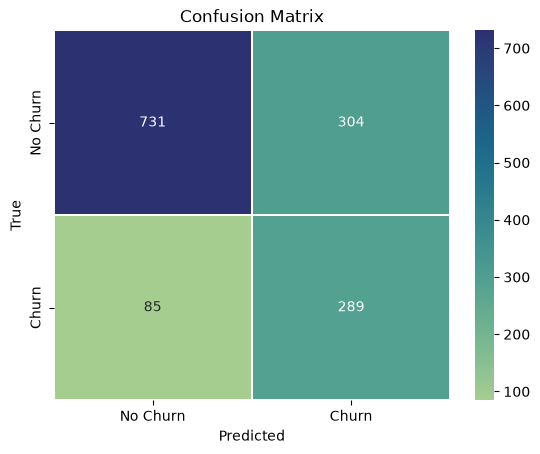

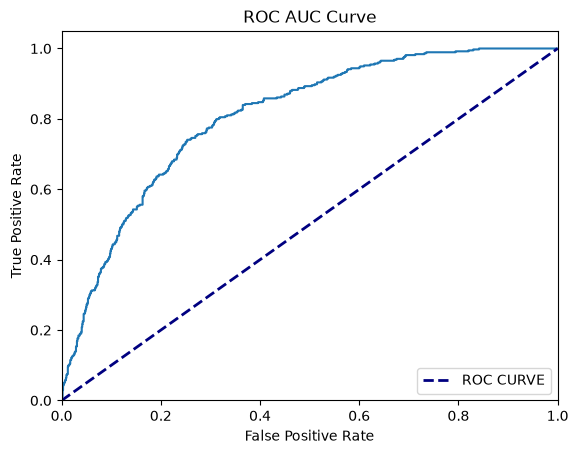

In [21]:
metrics(y_test, y_pred, y_pred_proba)

141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy score: 0.7366319059241181
recall score: 0.8060200668896321
precision score: 0.5023449713392392
f1 score: 0.6189406099518459
ROC-AUC score: 0.826271554532424
Classification Report
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      3311
           1       0.50      0.81      0.62      1196

    accuracy                           0.74      4507
   macro avg       0.71      0.76      0.71      4507
weighted avg       0.80      0.74      0.75      4507



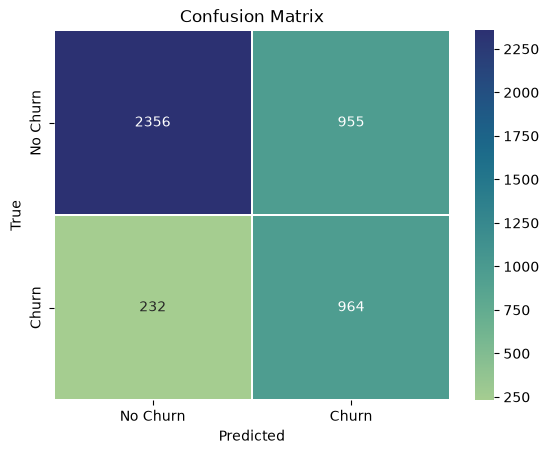

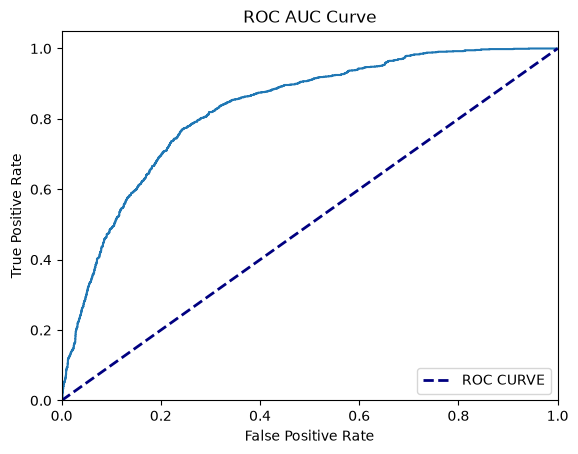

In [24]:
y_train_pred_proba = final_model.predict(X_train_processed)
y_train_pred = (y_train_pred_proba >= 0.5).astype(int)
metrics(y_train, y_train_pred, y_train_pred_proba)